# ANN (MLP) — WBCD baseline trên 3 feature paper

Dùng **MLPClassifier** (`sklearn.neural_network`) — ANN truyền thống có sẵn trong thư viện.

Pipeline bám `anfis_wbcd_pretrain_baseline.ipynb`:
- Tiền xử lý WBCD → **663 mẫu**, **đúng 3 feature** paper (v1/v2/v3)
- **Không split train/test** — fit trên toàn bộ 663 mẫu, predict luôn (phù hợp baseline thư viện)
- Kiểm tra tin cậy: assert shape, tên cột, `n_features_in_` của model
- Export metrics / predictions / model vào `models/`, biểu đồ vào `plots/`
- (Tuỳ chọn) So sánh với ANFIS đã train (70/30) qua cross-validation

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import pickle
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

models_dir = Path("models")
plots_dir = Path("plots")
models_dir.mkdir(exist_ok=True)
plots_dir.mkdir(exist_ok=True)

RUN_TAG = "ann_baseline"
COMPARE_ANFIS_STAMP = "20260628_172814"
COMPARE_ANFIS_TAG = "gridsearch_pca_feature_select"
COMPARE_SPLIT = "70_30"

In [2]:
# 1) Load WBCD goc + tien xu ly (giong notebook ANFIS)

uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"

cols = [
    "sample_code_number",
    "clump_thickness",
    "uniformity_of_cell_size",
    "uniformity_of_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "class",
]

df = pd.read_csv(uci_url, header=None, names=cols)
df = df.replace("?", np.nan).dropna().copy()
df["bare_nuclei"] = df["bare_nuclei"].astype(int)
df["target"] = (df["class"] == 4).astype(int)

feature_cols = [
    "clump_thickness",
    "uniformity_of_cell_size",
    "uniformity_of_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
]

PAPER_TOP3_FEATURES = [
    "clump_thickness",
    "uniformity_of_cell_size",
    "uniformity_of_cell_shape",
]

X = df[feature_cols].values.astype(np.float32)
y = df["target"].values.astype(int)

OUTLIER_STD_MULTIPLIER = 2.5
data_center = X.mean(axis=0)
euclidean_distances = np.linalg.norm(X - data_center, axis=1)
outlier_threshold = euclidean_distances.mean() + OUTLIER_STD_MULTIPLIER * euclidean_distances.std()
keep_mask = euclidean_distances <= outlier_threshold

X_clean = X[keep_mask]
y_clean = y[keep_mask]
df_clean = df.iloc[keep_mask].reset_index(drop=True)

scaler = StandardScaler()
X_norm = scaler.fit_transform(X_clean).astype(np.float32)

pca_full = PCA(n_components=9, random_state=42)
pca_full.fit(X_norm)

selected_idx = [feature_cols.index(c) for c in PAPER_TOP3_FEATURES]
X_selected = X_norm[:, selected_idx].astype(np.float32)

n_drop = len(X_selected) - 663
centroid_benign = X_selected[y_clean == 0].mean(axis=0)
centroid_malignant = X_selected[y_clean == 1].mean(axis=0)
dist_to_benign = np.linalg.norm(X_selected - centroid_benign, axis=1)
dist_to_malignant = np.linalg.norm(X_selected - centroid_malignant, axis=1)
own_dist = np.where(y_clean == 0, dist_to_benign, dist_to_malignant)
other_dist = np.where(y_clean == 0, dist_to_malignant, dist_to_benign)
quality_score = other_dist - own_dist

drop_idx = np.argsort(quality_score)[:n_drop]
quality_keep_mask = np.ones(len(X_selected), dtype=bool)
quality_keep_mask[drop_idx] = False

indices = np.where(quality_keep_mask)[0]
X_663 = X_selected[indices]
y_663 = y_clean[indices]
df_663 = df_clean.iloc[indices].reset_index(drop=True)

# DataFrame co ten cot — sklearn luu feature_names_in_
X_df = pd.DataFrame(X_663, columns=PAPER_TOP3_FEATURES)
y_series = pd.Series(y_663, name="target")

print(f"Mau sau tien xu ly: {len(X_df)}")
print(f"Feature dung cho ANN: {list(X_df.columns)}")
print(f"Shape X: {X_df.shape}")

Mau sau tien xu ly: 663
Feature dung cho ANN: ['clump_thickness', 'uniformity_of_cell_size', 'uniformity_of_cell_shape']
Shape X: (663, 3)


In [3]:
# 2) Kiem tra tin cay — chi 3 feature paper

def assert_three_paper_features(X_input, expected_names):
    if isinstance(X_input, pd.DataFrame):
        names = list(X_input.columns)
        n_feat = X_input.shape[1]
    else:
        names = expected_names
        n_feat = X_input.shape[1]
    assert n_feat == 3, f"Phai co dung 3 feature, hien co {n_feat}"
    assert names == expected_names, f"Ten feature sai: {names} != {expected_names}"
    return True


assert_three_paper_features(X_df, PAPER_TOP3_FEATURES)
print("OK — input chi gom 3 feature paper:", PAPER_TOP3_FEATURES)

OK — input chi gom 3 feature paper: ['clump_thickness', 'uniformity_of_cell_size', 'uniformity_of_cell_shape']


In [4]:
# 3) Train MLP tren TOAN BO 663 mau + predict luon

MLP_CONFIG = {
    "hidden_layer_sizes": (16,),
    "activation": "relu",
    "solver": "adam",
    "alpha": 1e-4,
    "batch_size": 32,
    "learning_rate_init": 1e-3,
    "max_iter": 500,
    "random_state": 42,
    "early_stopping": False,
}

ann_model = MLPClassifier(**MLP_CONFIG)
ann_model.fit(X_df, y_series)

y_pred = ann_model.predict(X_df)
y_score = ann_model.predict_proba(X_df)[:, 1]

# Kiem tra model chi nhan 3 feature
assert ann_model.n_features_in_ == 3, f"Model nhan {ann_model.n_features_in_} feature, khong phai 3"
assert list(ann_model.feature_names_in_) == PAPER_TOP3_FEATURES

print(f"MLP da fit — {ann_model.n_iter_} epoch, loss cuoi: {ann_model.loss_:.6f}")
print(f"n_features_in_: {ann_model.n_features_in_}")
print(f"feature_names_in_: {list(ann_model.feature_names_in_)}")
print(f"hidden_layer_sizes: {ann_model.hidden_layer_sizes}")

MLP da fit — 152 epoch, loss cuoi: 0.097536
n_features_in_: 3
feature_names_in_: ['clump_thickness', 'uniformity_of_cell_size', 'uniformity_of_cell_shape']
hidden_layer_sizes: (16,)


In [5]:
# 4) Metric tren tap du doan (663 mau, in-sample)

def evaluate_predictions(name, y_true, y_pred, y_score):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_score)
    except ValueError:
        auc = np.nan
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{name}")
    print("- Accuracy :", round(acc, 4))
    print("- Precision:", round(prec, 4))
    print("- Recall   :", round(rec, 4))
    print("- F1-score :", round(f1, 4))
    print("- ROC-AUC  :", round(auc, 4) if not np.isnan(auc) else "nan")
    print("- Confusion matrix:\n", cm)

    return {
        "split": name,
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1_score": float(f1),
        "roc_auc": None if np.isnan(auc) else float(auc),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "support": int(len(y_true)),
    }


full_metrics = evaluate_predictions("FULL_663 (in-sample)", y_663, y_pred, y_score)
full_metrics_df = pd.DataFrame([full_metrics])
display(full_metrics_df)


FULL_663 (in-sample)
- Accuracy : 0.9593
- Precision: 0.9369
- Recall   : 0.9412
- F1-score : 0.9391
- ROC-AUC  : 0.9928
- Confusion matrix:
 [[428  14]
 [ 13 208]]


,split,accuracy,precision,recall,f1_score,roc_auc,tn,fp,fn,tp,support
0,FULL_663 (in-sample),0.959276,0.936937,0.941176,0.939052,0.992788,428,14,13,208,663


In [6]:
# 5) Cross-validation 5-fold (danh gia khach quan, so sanh voi ANFIS)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    MLPClassifier(**MLP_CONFIG),
    X_df,
    y_series,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    return_train_score=False,
)

cv_summary = {
    "cv_folds": 5,
    "accuracy_mean": float(np.mean(cv_results["test_accuracy"])),
    "accuracy_std": float(np.std(cv_results["test_accuracy"])),
    "precision_mean": float(np.mean(cv_results["test_precision"])),
    "recall_mean": float(np.mean(cv_results["test_recall"])),
    "f1_mean": float(np.mean(cv_results["test_f1"])),
    "roc_auc_mean": float(np.mean(cv_results["test_roc_auc"])),
}

print("5-fold CV (chi 3 feature paper):")
for k, v in cv_summary.items():
    if k != "cv_folds":
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

# Doi chieu ANFIS neu co
anfis_metrics_path = models_dir / f"{COMPARE_ANFIS_STAMP}_{COMPARE_ANFIS_TAG}_{COMPARE_SPLIT}_metrics.json"
if anfis_metrics_path.exists():
    with open(anfis_metrics_path, encoding="utf-8") as f:
        anfis_ref = json.load(f)
    anfis_test = anfis_ref["metrics"]["TEST"]
    compare_df = pd.DataFrame([
        {
            "model": "ANN (MLP, 5-fold CV mean)",
            "accuracy": cv_summary["accuracy_mean"],
            "f1_score": cv_summary["f1_mean"],
            "roc_auc": cv_summary["roc_auc_mean"],
        },
        {
            "model": f"ANFIS ({COMPARE_SPLIT}, TEST)",
            "accuracy": anfis_test["accuracy"],
            "f1_score": anfis_test["f1_score"],
            "roc_auc": anfis_test.get("roc_auc"),
        },
    ])
    print("\n--- So sanh ANN vs ANFIS ---")
    display(compare_df)
else:
    print(f"\nKhong tim thay ANFIS metrics: {anfis_metrics_path.name}")

5-fold CV (chi 3 feature paper):
  accuracy_mean: 0.9593
  accuracy_std: 0.0139
  precision_mean: 0.9394
  recall_mean: 0.9411
  f1_mean: 0.9391
  roc_auc_mean: 0.9912

--- So sanh ANN vs ANFIS ---


,model,accuracy,f1_score,roc_auc
0,"ANN (MLP, 5-fold CV mean)",0.959296,0.939090,0.991236
1,"ANFIS (70_30, TEST)",0.944724,0.914729,NaN


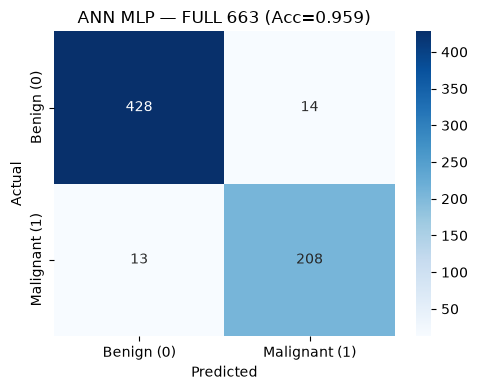

Da luu: plots\ann_cm_full_663.png


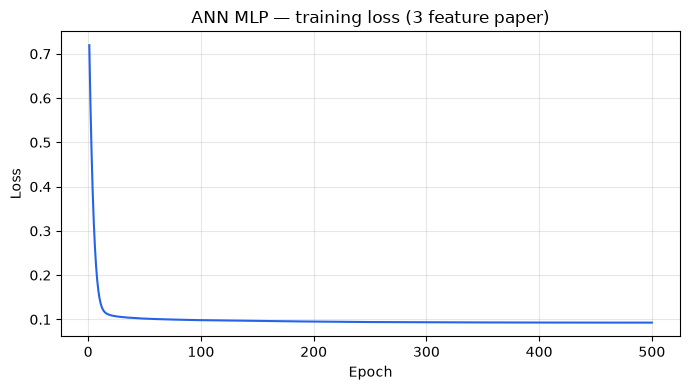

Da luu: plots\ann_loss_curve.png


In [7]:
# 6) Bieu do confusion matrix + loss curve

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
cm = confusion_matrix(y_663, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=ax,
    xticklabels=["Benign (0)", "Malignant (1)"],
    yticklabels=["Benign (0)", "Malignant (1)"],
)
ax.set_title(f"ANN MLP — FULL 663 (Acc={full_metrics['accuracy']:.3f})")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
cm_path = plots_dir / "ann_cm_full_663.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print("Da luu:", cm_path)

# Loss curve (warm_start loop)
loss_log = []
mlp_iter = MLPClassifier(**{**MLP_CONFIG, "warm_start": True, "max_iter": 1})
for epoch in range(1, 501):
    mlp_iter.fit(X_df, y_series)
    loss_log.append({"epoch": epoch, "loss": float(mlp_iter.loss_)})
    if mlp_iter.n_iter_ < 1:
        break

loss_df = pd.DataFrame(loss_log)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(loss_df["epoch"], loss_df["loss"], color="#2563eb")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("ANN MLP — training loss (3 feature paper)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
loss_path = plots_dir / "ann_loss_curve.png"
plt.savefig(loss_path, dpi=150, bbox_inches="tight")
plt.show()
print("Da luu:", loss_path)

In [8]:
# 7) Export ket qua

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")

metrics_json_path = models_dir / f"{stamp}_{RUN_TAG}_metrics.json"
metrics_csv_path = models_dir / f"{stamp}_{RUN_TAG}_metrics.csv"
pred_csv_path = models_dir / f"{stamp}_{RUN_TAG}_predictions.csv"
loss_csv_path = models_dir / f"{stamp}_{RUN_TAG}_training_loss_log.csv"
model_pkl_path = models_dir / f"{stamp}_{RUN_TAG}_model.pkl"
scaler_pkl_path = models_dir / f"{stamp}_{RUN_TAG}_scaler.pkl"

export_payload = {
    "created_at": stamp,
    "dataset": "UCI WBCD original",
    "model_type": "MLPClassifier (sklearn)",
    "training_mode": "full_663_no_split",
    "selected_features": PAPER_TOP3_FEATURES,
    "feature_validation": {
        "n_features_in": int(ann_model.n_features_in_),
        "feature_names_in": list(ann_model.feature_names_in_),
        "input_shape": list(X_df.shape),
    },
    "mlp_config": MLP_CONFIG,
    "full_663_in_sample": full_metrics,
    "cv_5fold": cv_summary,
    "n_iter": int(ann_model.n_iter_),
    "final_loss": float(ann_model.loss_),
}

with open(metrics_json_path, "w", encoding="utf-8") as f:
    json.dump(export_payload, f, indent=2, ensure_ascii=False)

metrics_rows = [full_metrics]
metrics_rows.append({
    "split": "CV_5FOLD_MEAN",
    "accuracy": cv_summary["accuracy_mean"],
    "precision": cv_summary["precision_mean"],
    "recall": cv_summary["recall_mean"],
    "f1_score": cv_summary["f1_mean"],
    "roc_auc": cv_summary["roc_auc_mean"],
    "tn": None, "fp": None, "fn": None, "tp": None,
    "support": len(y_663),
})
pd.DataFrame(metrics_rows).to_csv(metrics_csv_path, index=False)

pred_df = pd.DataFrame({
    "sample_code_number": df_663["sample_code_number"].astype(int).values,
    "split": "FULL",
    "y_true": y_663,
    "y_pred": y_pred.astype(int),
    "score": np.round(y_score, 6),
    "clump_thickness": X_df["clump_thickness"].values,
    "uniformity_of_cell_size": X_df["uniformity_of_cell_size"].values,
    "uniformity_of_cell_shape": X_df["uniformity_of_cell_shape"].values,
})
pred_df.to_csv(pred_csv_path, index=False)

loss_df.to_csv(loss_csv_path, index=False)

with open(model_pkl_path, "wb") as f:
    pickle.dump(ann_model, f)
with open(scaler_pkl_path, "wb") as f:
    pickle.dump({
        "scaler": scaler,
        "selected_features": PAPER_TOP3_FEATURES,
        "feature_cols": feature_cols,
        "selected_idx": selected_idx,
    }, f)

print("Da luu:")
for p in [
    metrics_json_path, metrics_csv_path, pred_csv_path,
    loss_csv_path, model_pkl_path, scaler_pkl_path,
    cm_path, loss_path,
]:
    print("-", p)

Da luu:
- models\20260629_113021_ann_baseline_metrics.json
- models\20260629_113021_ann_baseline_metrics.csv
- models\20260629_113021_ann_baseline_predictions.csv
- models\20260629_113021_ann_baseline_training_loss_log.csv
- models\20260629_113021_ann_baseline_model.pkl
- models\20260629_113021_ann_baseline_scaler.pkl
- plots\ann_cm_full_663.png
- plots\ann_loss_curve.png
